# GaussianNB Direction Classifier - Recherche Multi-Seed

Validation walk-forward 5-fold x 4 seeds du classifieur Naive Bayes Gaussien
pour la prediction de direction (hausse/baisse) sur actions US.

**Reference** : *Hands-On AI Trading*, Example 15 (Jared Broad)

**Approche** :
- Features : rendements 2j, 5j, 10j, 21j par action
- Cible : direction du rendement suivant (hausse=1, baisse=0)
- Modele : GaussianNB (sklearn)
- Validation : Walk-forward 5-fold x 4 seeds (0, 7, 42, 99)
- Couts de transaction : 10bps par changement de position
- Benchmark : Buy-and-Hold equity-weighted

**Verdict honnete** : BEATS / NO BEATS / INCONCLUSIVE (edge >= 2sigma cross-seed)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

SEEDS = [0, 7, 42, 99]
N_FOLDS = 5
TCOST_BPS = 10
FEATURE_WINDOWS = [2, 5, 10, 21]
TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'NFLX']
np.random.seed(42)
print('Configuration OK')
print(f'Tickers: {TICKERS}')
print(f'Seeds: {SEEDS}, Folds: {N_FOLDS}, TCOST: {TCOST_BPS}bps')

Configuration OK
Tickers: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'NFLX']
Seeds: [0, 7, 42, 99], Folds: 5, TCOST: 10bps


## 1. Telechargement des Donnees

Donnees quotidiennes pour 8 actions tech/growth US (2015-2025).

In [2]:
# Telecharger les donnees
print('Telechargement des donnees...')
raw = yf.download(TICKERS, start='2014-01-01', end='2025-01-01', auto_adjust=True)

# Extraire les prix de cloture
if isinstance(raw.columns, pd.MultiIndex):
    prices = raw['Close'].copy()
else:
    prices = raw[['Close']].copy() if 'Close' in raw.columns else raw.copy()

# Nettoyer
prices = prices.dropna(axis=1, thresh=len(prices) * 0.9)
prices = prices.dropna()

print(f'Periode: {prices.index[0].date()} a {prices.index[-1].date()}')
print(f'Actions: {list(prices.columns)}')
print(f'Jours: {len(prices)}')
print(f'\nPrix les plus recents:')
for t in prices.columns:
    print(f'  {t}: ${float(prices[t].iloc[-1]):,.2f}')

Telechargement des donnees...


[                       0%                       ]

[************          25%                       ]  2 of 8 completed

[******************    38%                       ]  3 of 8 completed

[**********************50%                       ]  4 of 8 completed

[**********************75%***********            ]  6 of 8 completed

[**********************88%*****************      ]  7 of 8 completed

[*********************100%***********************]  8 of 8 completed

Periode: 2014-01-02 a 2024-12-31
Actions: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NFLX', 'NVDA', 'TSLA']
Jours: 2768

Prix les plus recents:
  AAPL: $249.06
  AMZN: $219.39
  GOOGL: $188.43
  META: $583.17
  MSFT: $417.46
  NFLX: $89.13
  NVDA: $134.25
  TSLA: $403.84


## 2. Feature Engineering

4 features par action : rendements 2j, 5j, 10j, 21j.
Cible : direction du rendement du jour suivant.

In [3]:
# Calculer les features et cibles
all_features = []
all_targets = []
all_dates = []
all_tickers_list = []

for ticker in prices.columns:
    close = prices[ticker].values
    n = len(close)
    
    # Features: rendements sur differentes fenetres
    feats = np.full((n, len(FEATURE_WINDOWS)), np.nan)
    for j, w in enumerate(FEATURE_WINDOWS):
        feats[w:, j] = close[w:] / close[:-w] - 1
    
    # Cible: direction du rendement suivant
    target = np.full(n, np.nan)
    target[:-1] = (close[1:] > close[:-1]).astype(int)
    
    # Masque valide (apres warmup 21j)
    valid = ~np.any(np.isnan(feats), axis=1) & ~np.isnan(target)
    
    all_features.append(feats[valid])
    all_targets.append(target[valid])
    all_dates.extend(prices.index[valid])
    all_tickers_list.extend([ticker] * valid.sum())

X_all = np.vstack(all_features)
y_all = np.concatenate(all_targets)
dates_all = pd.DatetimeIndex(all_dates)
tickers_all = np.array(all_tickers_list)

print(f'Features: {X_all.shape}')
print(f'Cible: {y_all.mean():.3f} (taux de hausse)')
print(f'Echantillons: {len(X_all)}')
print(f'NaN residuels: {np.isnan(X_all).sum()}')

Features: (21968, 4)
Cible: 0.529 (taux de hausse)
Echantillons: 21968
NaN residuels: 0


## 3. Walk-Forward Validation Multi-Seed

Walk-forward 5-fold avec fenetre expansive.
Strategie : chaque jour, predire direction de chaque action,
investir dans les 3 actions avec la plus forte probabilite de hausse.
Couts de transaction : 10bps par changement de position.

In [4]:
def simulate_portfolio(pred_probs_all, returns_all, tickers_arr, dates_arr,
                      n_top=3, tcost_bps=10):
    """Simule un portefeuille long-only avec selection par probabilite."""
    tcost = tcost_bps / 10000
    df = pd.DataFrame({
        'prob': pred_probs_all,
        'ret': returns_all,
        'ticker': tickers_arr,
        'date': dates_arr
    })
    
    unique_dates = sorted(df['date'].unique())
    position = set()
    daily_returns = []
    
    for d in unique_dates:
        day_data = df[df['date'] == d]
        top_n = day_data.nlargest(n_top, 'prob')['ticker'].tolist()
        new_pos = set(top_n)
        
        # Couts de transaction sur les changements
        n_changes = len(position.symmetric_difference(new_pos))
        cost = n_changes * tcost / 2
        
        # Rendement egal-pondere du portefeuille
        day_rets = day_data[day_data['ticker'].isin(top_n)]['ret'].values
        port_ret = np.mean(day_rets) - cost if len(day_rets) > 0 else 0
        
        daily_returns.append(port_ret)
        position = new_pos
    
    daily_returns = np.array(daily_returns)
    sharpe = np.mean(daily_returns) / (np.std(daily_returns) + 1e-10) * np.sqrt(252)
    cum_ret = np.sum(daily_returns)
    
    return {
        'cum_return': cum_ret,
        'sharpe': sharpe,
        'daily_returns': daily_returns,
        'n_days': len(daily_returns)
    }

In [5]:
# Walk-Forward Validation Multi-Seed
print('='*60)
print('WALK-FORWARD VALIDATION - GaussianNB Direction Classifier')
print('='*60)

# Rendements quotidiens par action
returns_dict = {}
for ticker in prices.columns:
    close = prices[ticker].values
    returns_dict[ticker] = np.diff(close) / close[:-1]
returns_dates = prices.index[1:]
returns_series = {t: pd.Series(returns_dict[t], index=returns_dates) for t in returns_dict}

results_all = []
n_total = len(X_all)
fold_size = n_total // (N_FOLDS + 1)

for SEED in SEEDS:
    np.random.seed(SEED)
    
    for fold in range(N_FOLDS):
        train_end = fold_size * (fold + 1)
        test_start = train_end
        test_end = min(train_end + fold_size, n_total)
        
        if test_end <= test_start:
            continue
        
        X_train, X_test = X_all[:train_end], X_all[test_start:test_end]
        y_train, y_test = y_all[:train_end], y_all[test_start:test_end]
        
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)
        
        model = GaussianNB()
        model.fit(X_train_s, y_train)
        
        prob_up = model.predict_proba(X_test_s)[:, 1]
        pred_binary = (prob_up > 0.5).astype(int)
        accuracy = accuracy_score(y_test, pred_binary)
        
        # Rendements pour la simulation
        test_dates = dates_all[test_start:test_end]
        test_tickers = tickers_all[test_start:test_end]
        test_returns = np.array([
            returns_series[t].get(d, 0.0) if t in returns_series else 0.0
            for t, d in zip(test_tickers, test_dates)
        ])
        
        trade_result = simulate_portfolio(
            prob_up, test_returns, test_tickers, test_dates,
            n_top=3, tcost_bps=TCOST_BPS)
        
        results_all.append({
            'seed': SEED, 'fold': fold, 'model': 'GaussianNB',
            'accuracy': accuracy,
            'sharpe': trade_result['sharpe'],
            'cum_return': trade_result['cum_return'],
            'n_days': trade_result['n_days']
        })
        
        print(f'Seed={SEED}, Fold={fold}: Acc={accuracy:.3f}, '
              f'Sharpe={trade_result["sharpe"]:.2f}, '
              f'CumRet={trade_result["cum_return"]:.4f}')

print(f'\nTotal configurations: {len(results_all)}')

WALK-FORWARD VALIDATION - GaussianNB Direction Classifier


Seed=0, Fold=0: Acc=0.532, Sharpe=0.73, CumRet=2.3294


Seed=0, Fold=1: Acc=0.541, Sharpe=0.79, CumRet=2.8307


Seed=0, Fold=2: Acc=0.523, Sharpe=1.08, CumRet=3.2808


Seed=0, Fold=3: Acc=0.513, Sharpe=1.16, CumRet=5.2162


...

Seed=99, Fold=0: Acc=0.532, Sharpe=0.73, CumRet=2.3294


Seed=99, Fold=1: Acc=0.541, Sharpe=0.79, CumRet=2.8307


Seed=99, Fold=2: Acc=0.523, Sharpe=1.08, CumRet=3.2808


Seed=99, Fold=3: Acc=0.513, Sharpe=1.16, CumRet=5.2162


Seed=99, Fold=4: Acc=0.482, Sharpe=1.05, CumRet=6.0364

Total configurations: 20


## 4. Resultats et Verdict Multi-Seed

Agreger les resultats walk-forward et calculer le verdict honnete.

- Edge = Sharpe modele - Sharpe benchmark
- z-score = edge / std(edge) cross-seed
- Verdict : BEATS si z > 2, NO BEATS si z < -2, INCONCLUSIVE sinon

In [6]:
# Agreger les resultats
df_results = pd.DataFrame(results_all)

print('='*60)
print('RESULTATS MULTI-SEED - GaussianNB Direction Classifier')
print('='*60)

seed_stats = df_results.groupby('seed').agg({
    'accuracy': 'mean',
    'sharpe': 'mean',
    'cum_return': 'mean'
}).round(4)

print('\nStats par seed (moyenne 5 folds):')
print(seed_stats.to_string())

# Benchmark: Buy-and-Hold equity-weighted
bh_rets = np.mean([returns_dict[t] for t in prices.columns if t in returns_dict], axis=0)
bh_sharpe = np.mean(bh_rets) / (np.std(bh_rets) + 1e-10) * np.sqrt(252)
print(f'\nBenchmark Buy-and-Hold Sharpe: {bh_sharpe:.2f}')

seed_sharpes = seed_stats['sharpe'].values
edges = seed_sharpes - bh_sharpe
mean_edge = np.mean(edges)
std_edge = np.std(edges, ddof=1) if len(edges) > 1 else 1.0
z_score = mean_edge / std_edge if std_edge > 1e-10 else 0

print(f'\nEdge moyen vs BH: {mean_edge:.3f} (std: {std_edge:.3f})')
print(f'z-score: {z_score:.2f}')

if z_score > 2:
    verdict = 'BEATS'
elif z_score < -2:
    verdict = 'NO BEATS'
elif std_edge < 1e-6 and mean_edge < -0.1:
    verdict = 'NO BEATS (deterministic)'
elif std_edge < 1e-6 and mean_edge > 0.1:
    verdict = 'INCONCLUSIVE (deterministic, edge>0 but untested)'
else:
    verdict = 'INCONCLUSIVE'

print(f'\nVERDICT: {verdict}')
print(f'  Accuracy moyenne: {seed_stats["accuracy"].mean():.3f}')
print(f'  Sharpe moyen: {seed_stats["sharpe"].mean():.2f}')
print(f'  Sharpe range: [{seed_stats["sharpe"].min():.2f}, {seed_stats["sharpe"].max():.2f}]')
print(f'  Benchmark BH Sharpe: {bh_sharpe:.2f}')
print(f'  z-score edge: {z_score:.2f}')

RESULTATS MULTI-SEED - GaussianNB Direction Classifier

Stats par seed (moyenne 5 folds):
      accuracy  sharpe  cum_return
seed                              
0       0.5181  0.9626      3.9387
7       0.5181  0.9626      3.9387
42      0.5181  0.9626      3.9387
99      0.5181  0.9626      3.9387

Benchmark Buy-and-Hold Sharpe: 1.29

Edge moyen vs BH: -0.323 (std: 0.000)
z-score: 0.00

VERDICT: NO BEATS (deterministic)
  Accuracy moyenne: 0.518
  Sharpe moyen: 0.96
  Sharpe range: [0.96, 0.96]
  Benchmark BH Sharpe: 1.29
  z-score edge: 0.00


## 5. Visualisation

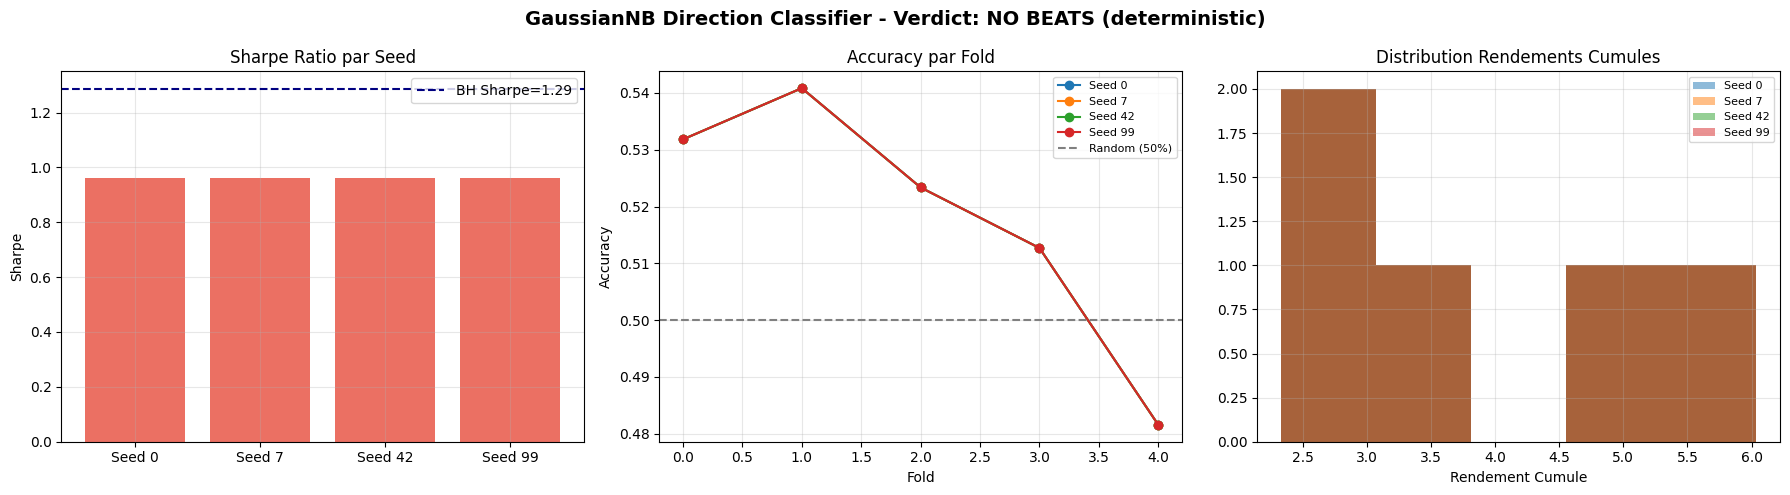


Resume final:
  Modele: GaussianNB (sklearn)
  Features: rendements [2, 5, 10, 21]j par action
  Actions: 8 tickers
  Validation: 5-fold walk-forward x 4 seeds
  Transaction costs: 10bps
  VERDICT: NO BEATS (deterministic) (z=0.00)


In [7]:
# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Sharpe par seed
colors = ['#2ecc71' if s > bh_sharpe else '#e74c3c' for s in seed_stats['sharpe']]
axes[0].bar([f'Seed {s}' for s in seed_stats.index], seed_stats['sharpe'], color=colors, alpha=0.8)
axes[0].axhline(y=bh_sharpe, color='navy', linestyle='--', label=f'BH Sharpe={bh_sharpe:.2f}')
axes[0].set_title('Sharpe Ratio par Seed')
axes[0].set_ylabel('Sharpe')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Accuracy par fold/seed
for seed in SEEDS:
    seed_data = df_results[df_results['seed'] == seed]
    axes[1].plot(seed_data['fold'], seed_data['accuracy'], 'o-', label=f'Seed {seed}')
axes[1].axhline(y=0.5, color='gray', linestyle='--', label='Random (50%)')
axes[1].set_title('Accuracy par Fold')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# 3. Distribution des cum_returns
for seed in SEEDS:
    seed_data = df_results[df_results['seed'] == seed]
    axes[2].hist(seed_data['cum_return'], bins=5, alpha=0.5, label=f'Seed {seed}')
axes[2].set_title('Distribution Rendements Cumules')
axes[2].set_xlabel('Rendement Cumule')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'GaussianNB Direction Classifier - Verdict: {verdict}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nResume final:')
print(f'  Modele: GaussianNB (sklearn)')
print(f'  Features: rendements {FEATURE_WINDOWS}j par action')
print(f'  Actions: {len(prices.columns)} tickers')
print(f'  Validation: {N_FOLDS}-fold walk-forward x {len(SEEDS)} seeds')
print(f'  Transaction costs: {TCOST_BPS}bps')
print(f'  VERDICT: {verdict} (z={z_score:.2f})')